Sample Exercise 4 notebook

In [82]:
import pandas as pd
import os
import likert
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

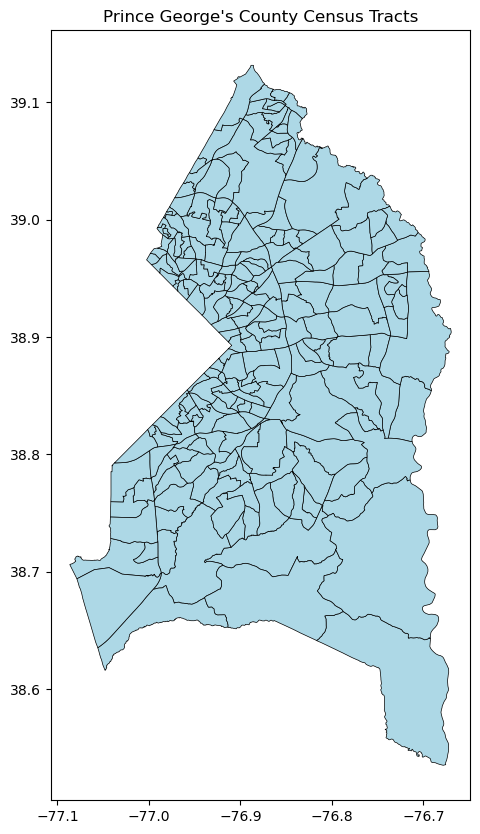

In [104]:
#Create a map of Prince George's County Census Tracts
#Access Maryland Tracts 
url = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_24_tract.zip"
md_tracts = gpd.read_file(url)

#Only view tracts in Prince George's County
pg_tracts = md_tracts[md_tracts['COUNTYFP'] == '033']

#Plot the map
fig, ax = plt.subplots(figsize = (10, 10))
ax.set_title("Prince George's County Census Tracts")
pg_tracts.plot(ax = ax, edgecolor = 'black', facecolor = 'lightblue', linewidth = 0.5)
plt.show()

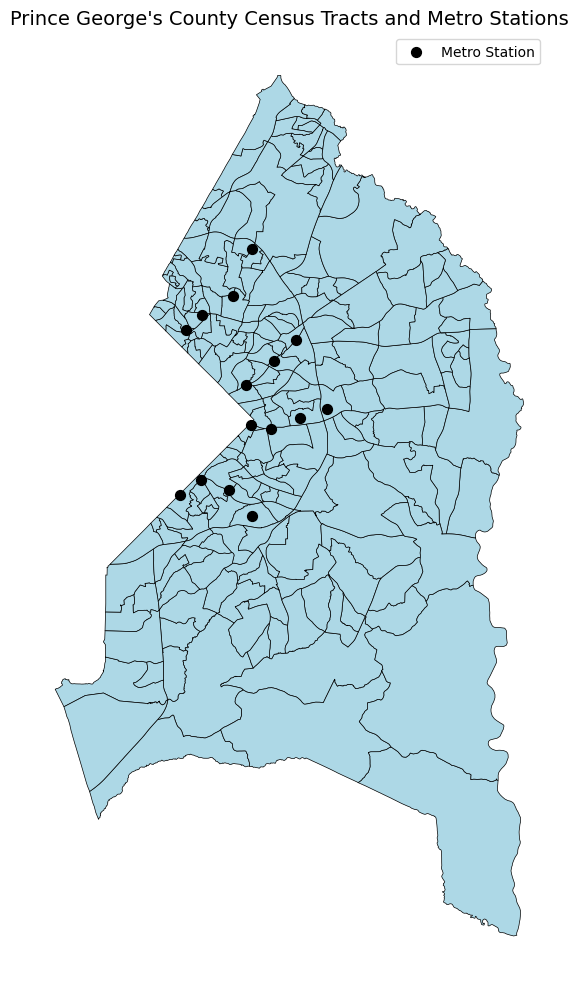

In [107]:
#Overlay WMATA Metrostops

stations = gpd.read_file('Metro_Stations_Regional.geojson')

url = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_24_tract.zip"
md_tracts = gpd.read_file(url)

#Only view tracts in Prince George's County.
pg_tracts = md_tracts[md_tracts['COUNTYFP'] == '033']

stations = stations.to_crs(pg_tracts.crs)

#Only show stations within the county.
pg_boundary = pg_tracts.dissolve()
metro_pg = gpd.clip(stations, pg_boundary)

#Plot the station map
fig, ax = plt.subplots(figsize=(10, 10))


pg_tracts.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
metro_pg.plot(ax=ax, color='black', markersize=50, zorder=5, label='Metro Station')

ax.set_title("Prince George's County Census Tracts and Metro Stations", fontsize=14)
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


In [73]:
#Create layered 0.5, 1-mile, and 2-mile buffers around each station.

#Ensure both maps are in the same projection.
pg_tracts_proj = pg_tracts.to_crs(epsg=6487)
metro_pg_proj = metro_pg.to_crs(epsg=6487)

#Create buffers
buffer_half = metro_pg_proj.buffer(1609.34 * 0.5)
buffer_1mile = metro_pg_proj.buffer(1609.34 * 1)
buffer_2mile = metro_pg_proj.buffer(1609.34 * 2)

#Create Geodataframes
gdf_half  = gpd.GeoDataFrame(geometry=buffer_half,  crs=pg_tracts_proj.crs)
gdf_1mile = gpd.GeoDataFrame(geometry=buffer_1mile, crs=pg_tracts_proj.crs)
gdf_2mile = gpd.GeoDataFrame(geometry=buffer_2mile, crs=pg_tracts_proj.crs)

#Remove overlapping effect of the buffers.
gdf_half  = gdf_half.dissolve()
gdf_1mile = gdf_1mile.dissolve()
gdf_2mile = gdf_2mile.dissolve()


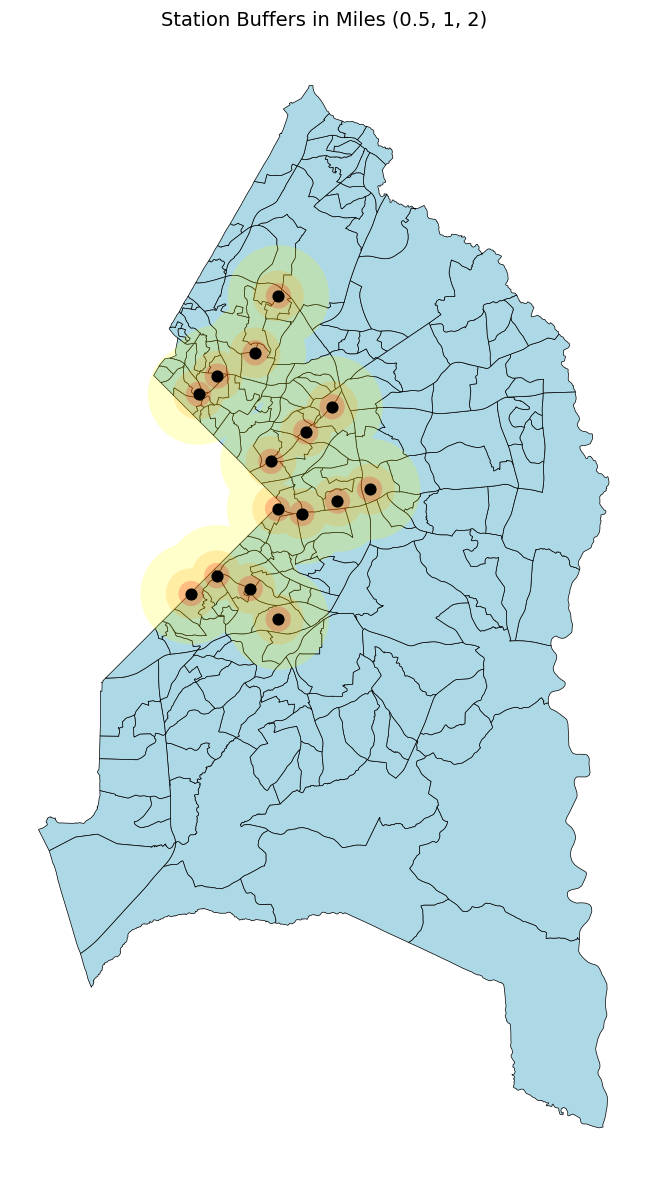

In [113]:

#Plot the Station Buffer Maps
fig, ax = plt.subplots(figsize=(12, 12))
pg_tracts_proj.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)

#Plot buffers
gdf_2mile.plot(ax=ax, color='yellow', alpha=0.2, label='2-Mile Buffer')
gdf_1mile.plot(ax=ax, color='orange', alpha=0.2, label='1-Mile Buffer')
gdf_half.plot(ax=ax,  color='red', alpha=0.2, label='0.5-Mile Buffer')

# Metro stations on top
metro_pg_proj.plot(ax=ax, color='black', markersize=60, zorder=5, label='Metro Station')

ax.set_title("Station Buffers in Miles (0.5, 1, 2)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [ ]:
#Import the Mile 1 QOL Example Survey. This would be also done for the 0.5 and 2 mile buffers.
mile_1_df = pd.read_csv("mile_1_QOL.csv")

In [19]:
mile_1_df

,Index,Question,1: Strongly Disagree,2: Disagree,3: Neutral,4: Agree,5: Strongly Agree
0,0,I require a car to commute daily needs. (ex. W...,27,18,19,16,20
1,1,My transportation options have prevented me fr...,21,16,20,15,28
2,2,I am satisfied with my ability to walk in my c...,25,14,15,21,25
3,3,I am satisfied with my proximity to a Metro st...,20,17,16,23,24
4,4,I feel connected to my community.,18,18,20,20,24
5,5,I feel safe when using or living near a Metro ...,19,20,27,20,14


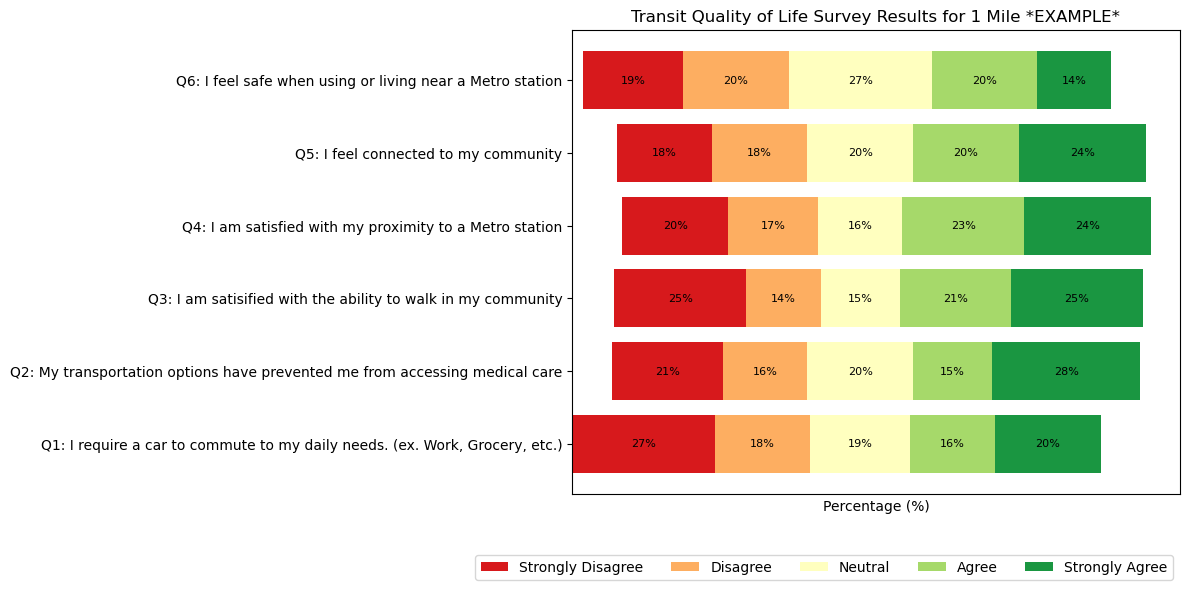

In [44]:
#Create a bar-graph to visualize the sample Likert results. 

data = pd.DataFrame({
    'Q1: I require a car to commute to my daily needs. (ex. Work, Grocery, etc.)': [27, 18, 19, 16, 20],
    'Q2: My transportation options have prevented me from accessing medical care': [21, 16, 20, 15, 28],
    'Q3: I am satisified with the ability to walk in my community': [25, 14, 15, 21, 25],
    'Q4: I am satisfied with my proximity to a Metro station': [20, 17, 16, 23, 24],
    'Q5: I feel connected to my community': [18, 18, 20, 20, 24],
    'Q6: I feel safe when using or living near a Metro station': [19, 20, 27, 20, 14],
}, index = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']).T

#Add colors and labels 
colors = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
labels = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']

fig, ax = plt.subplots(figsize=(12, 6))

#Start left edge: negative cols + half of neutral (AI assisted with this)
lefts = -(data['Strongly Disagree'] + data['Disagree'] + data['Neutral'] / 2)

for col, color, label in zip(labels, colors, labels):
    bars = ax.barh(data.index, data[col], left=lefts, color=color, label=label, edgecolor='none')
    for bar, val in zip(bars, data[col]):
        if val >= 8:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val}%', ha='center', va='center', fontsize=8, color='black')
    lefts += data[col]

#Label x-axis and create a legend.
ax.set_xlabel('Percentage (%)')
ax.set_title('Transit Quality of Life Survey Results for 1 Mile *EXAMPLE*')
ax.legend(loc='lower right', bbox_to_anchor=(1.0, -0.2), ncol=5)
ax.set_xticks([])

plt.tight_layout()
plt.show()